# Homework 6
You need to classify digits with SVM models in this homework. Use PCA to reduce data dimensionality (80% information remain). Compare performance of linear, radial, and polynomial kernals. Tune kernal parameters using Randomsearch method.

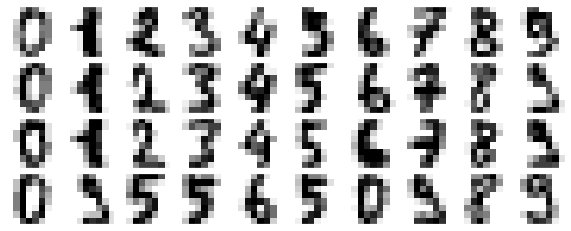

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()
from sklearn import datasets, metrics
from sklearn.svm import SVC as svc

from sklearn.model_selection import train_test_split, RandomizedSearchCV

# The digits dataset
digits = datasets.load_digits()

def plot_digits(data):
    fig, axes = plt.subplots(4, 10, figsize=(10, 4),
                             subplot_kw={'xticks':[], 'yticks':[]},
                             gridspec_kw=dict(hspace=0.1, wspace=0.1))
    for i, ax in enumerate(axes.flat):
        ax.imshow(data[i].reshape(8, 8),
                  cmap='binary', interpolation='nearest',
                  clim=(0, 16))
plot_digits(digits.data)

In [2]:
from sklearn.decomposition import PCA
pca = PCA(0.8).fit(digits.data)
pca.n_components_

13

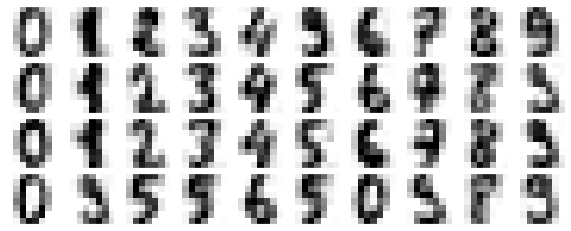

In [3]:
components = pca.transform(digits.data)
reduced_X = pca.inverse_transform(components)
plot_digits(reduced_X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(reduced_X, digits.target, test_size = 0.33, random_state=42)

In [5]:
from sklearn.utils.fixes import loguniform

linear_param = {'C': loguniform(1e-3, 1e2),
                'kernel':['linear'],
                'class_weight':['balanced', None]}
rbf_param = {'C': loguniform(1e-3, 1e2),
            'gamma': loguniform(1e-3, 1e2),
            'kernel':['rbf'],
            'class_weight':['balanced', None]}
poly_param = {'C': loguniform(1e-3, 1e2),
            'gamma': loguniform(1e-3, 1e2),
            'kernel':['poly'],
            'degree': [2, 3, 4, 5],
            'class_weight':['balanced', None]}

linearModel = RandomizedSearchCV(svc(probability = True, random_state = 1), linear_param, n_iter = 100, cv = 5, random_state = 0)
linearSearch = linearModel.fit(X_train, y_train)
print(linearSearch.best_params_)



radialModel = RandomizedSearchCV(svc(probability = True, random_state = 1), rbf_param, n_iter = 100, cv = 5, random_state = 0)
radialSearch = radialModel.fit(X_train, y_train)
print(radialSearch.best_params_)


polyModel = RandomizedSearchCV(svc(probability = True, random_state = 1), poly_param, n_iter = 100, cv = 5, random_state = 0)
polySearch = polyModel.fit(X_train, y_train)
print(polySearch.best_params_)


{'C': 0.0014727379143465189, 'class_weight': 'balanced', 'kernel': 'linear'}
{'C': 1.3008597541185905, 'class_weight': 'balanced', 'gamma': 0.003023375152147207, 'kernel': 'rbf'}
{'C': 0.0039027625535532928, 'class_weight': 'balanced', 'degree': 3, 'gamma': 0.0052091448868898885, 'kernel': 'poly'}


In [8]:
y_lin_pred = linearSearch.predict(X_test)
print("Linear Kernal Accuracy " + str(metrics.accuracy_score(y_lin_pred, y_test)))

y_rad_pred = radialSearch.predict(X_test)
print("Radial Kernel Accuracy " + str(metrics.accuracy_score(y_rad_pred, y_test)))

y_poly_pred = polySearch.predict(X_test)
print("Polynomial Kernal Accuracy " + str(metrics.accuracy_score(y_poly_pred, y_test)))


Linear Kernal Accuracy 0.9663299663299664
Radial Kernel Accuracy 0.98989898989899
Polynomial Kernal Accuracy 0.9831649831649831
